# 03 · RUL model comparison on real C-MAPSS

Reads `reports/experiments/*.json` (produced by `make eval`). Every experiment uses engine-grouped
5-fold CV on the training file for selection and scores the official test file once, at each
engine's last cycle, with RUL capped at 125.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "reference"
REPORTS = ROOT / "reports"

# Reference categorical palette (fixed order) and recessive chart chrome.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c2", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

In [2]:
ORDER = ["mean_baseline", "serving_ridge_uncapped", "serving_ridge", "offline_ridge",
         "offline_quadratic_ridge", "offline_rff_ridge"]
DOMAINS = ("FD001", "FD002", "FD003", "FD004")
runs = {n: json.loads((REPORTS / "experiments" / f"{n}.json").read_text()) for n in ORDER}
print(f"{'experiment':<25}" + "".join(f"{d:>14}" for d in DOMAINS))
for name, run in runs.items():
    cells = [run["results"][d]["test"]["rmse"] for d in DOMAINS]
    print(f"{name:<25}" + "".join(f"{c['mean']:>9.2f} ±{c['std']:.2f}" for c in cells))

experiment                        FD001         FD002         FD003         FD004
mean_baseline                41.94 ±0.00    44.93 ±0.00    43.70 ±0.00    45.57 ±0.00
serving_ridge_uncapped       32.00 ±0.00    39.08 ±0.00    54.59 ±0.00    60.03 ±0.00
serving_ridge                22.25 ±0.00    28.99 ±0.00    21.92 ±0.00    37.10 ±0.00
offline_ridge                18.33 ±0.00    18.46 ±0.00    17.99 ±0.00    21.86 ±0.00
offline_quadratic_ridge      16.59 ±0.00    16.82 ±0.00    15.98 ±0.00    18.86 ±0.00
offline_rff_ridge            14.46 ±0.14    14.22 ±0.14    14.47 ±0.21    16.01 ±0.20


## Test RMSE by experiment

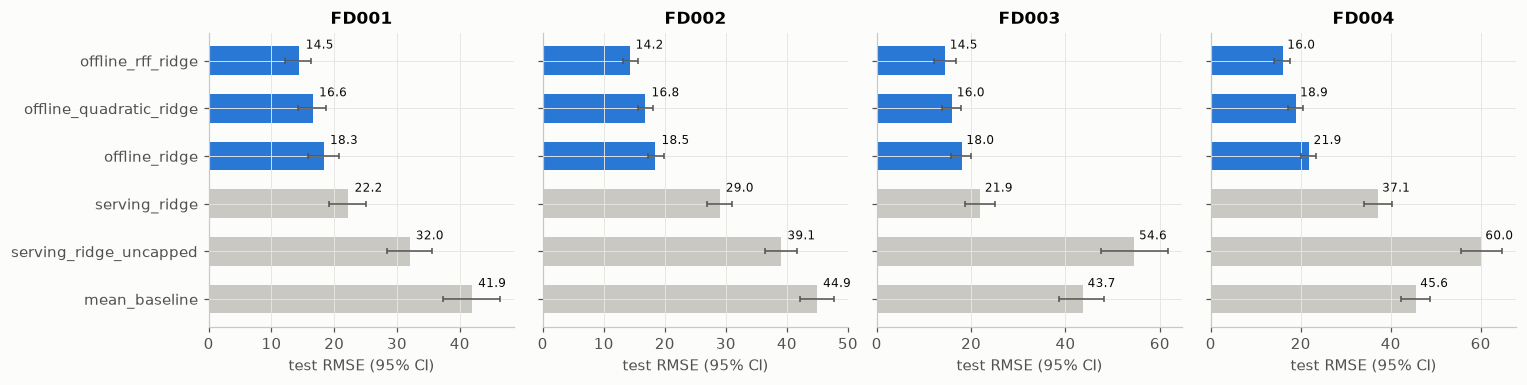

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, domain in zip(axes, DOMAINS):
    means = [runs[n]["results"][domain]["test"]["rmse"]["mean"] for n in ORDER]
    low_high = [runs[n]["results"][domain]["test"]["rmse_ci95_seed0"] for n in ORDER]
    errors = np.array([[m - lo, hi - m] for m, (lo, hi) in zip(means, low_high)]).T
    colors = ["#c9c8c2"] * 3 + [BLUE] * 3
    ax.barh(range(len(ORDER)), means, color=colors, height=0.6, xerr=errors,
            error_kw={"ecolor": "#52514e", "elinewidth": 1, "capsize": 2})
    for i, m in enumerate(means):
        ax.text(m + 1, i + 0.25, f"{m:.1f}", fontsize=8, color="#0b0b0b")
    ax.set(title=domain, xlabel="test RMSE (95% CI)")
    ax.invert_yaxis()
axes[0].set_yticks(range(len(ORDER)), ORDER)
plt.tight_layout()

Gray: the serving feature contract; blue: offline features. The biggest single gains are the
RUL cap (uncapped → capped), per-regime normalization with rolling features (FD002/FD004), and
the nonlinear kernel model.

## Where the best model errs

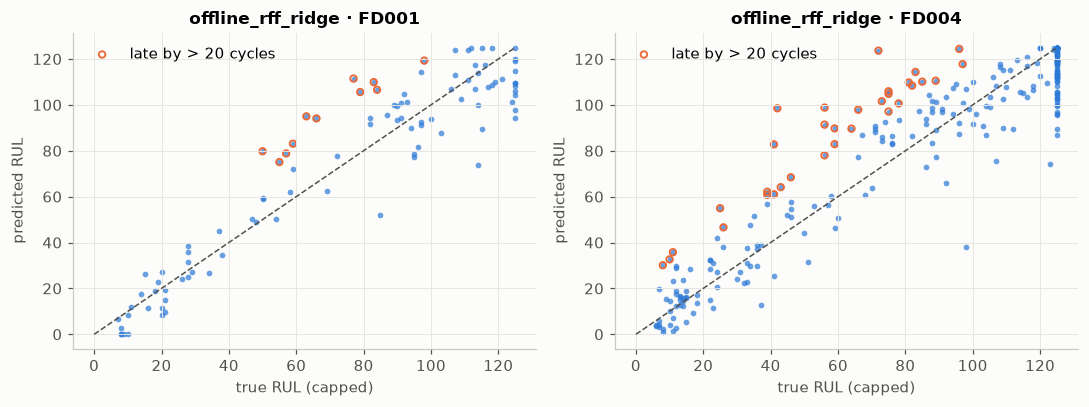

In [4]:
best = runs["offline_rff_ridge"]["results"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, domain in zip(axes, ("FD001", "FD004")):
    true = np.minimum(np.array(best[domain]["predictions_seed0"]["true_rul"]), 125)
    pred = np.array(best[domain]["predictions_seed0"]["predicted"])
    ax.scatter(true, pred, s=14, color=BLUE, alpha=0.7, linewidths=0)
    ax.plot([0, 125], [0, 125], color="#52514e", linestyle="--", linewidth=1)
    late = (pred - true) > 20
    ax.scatter(true[late], pred[late], s=18, facecolors="none", edgecolors=ORANGE, linewidths=1.2,
               label="late by > 20 cycles")
    ax.set(title=f"offline_rff_ridge · {domain}", xlabel="true RUL (capped)", ylabel="predicted RUL")
    ax.legend(loc="upper left")
plt.tight_layout()

Late predictions (above the diagonal) dominate the NASA score because it penalizes them
exponentially. They come from engines with shorter observed histories and lower true RUL: on
FD001 the 11 engines predicted more than 20 cycles late have a median of 113 observed cycles
(137 for the rest) and true RUL 66 (91); on FD004 the 32 late engines have 121.5 observed cycles
(158.5) and true RUL 59 (95.5). The 30-cycle rolling window simply has less evidence of wear yet.